# **Dataset Cleaning**

**source:**

https://www.kaggle.com/datasets/adityakadiwal/water-potability

A Machine Learning-Based Water Potability Prediction Model by Using Synthetic Minority Oversampling Technique and Explainable AI : https://onlinelibrary.wiley.com/doi/epdf/10.1155/2022/9283293

In [130]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.svm import SVC

In [ ]:
data_path = "dataset/water Quality (kaggle)/water_potability.csv"
df = pd.read_csv(data_path)
df_copy = df.copy()

- ph: pH of 1. water (0 to 14).
- vHardness: Capacity of water to precipitate soap in mg/L.
- Solids: Total dissolved solids in ppm.
- Chloramines: Amount of Chloramines in ppm.
- Sulfate: Amount of Sulfates dissolved in mg/L.
- Conductivity: Electrical conductivity of water in μS/cm.
- Organic_carbon: Amount of organic carbon in ppm.
- Trihalomethanes: Amount of Trihalomethanes in μg/L.
- Turbidity: Measure of light emiting property of water in NTU.
- Potability: Indicates if water is safe for human consumption. Potable -1 and Not potable -0

### **Handling NaN values**

In [44]:
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Best practice is **Class-wise imputation.**

Fill NaNs using median within each potability class. This keeps differences between drinkable vs non-drinkable water.

In [111]:
for col in df.columns:
    if col != 'Potability':
        df[col] = df.groupby('Potability')[col].transform(lambda x: x.fillna(x.median()))

In [112]:
df.fillna(df.median(numeric_only=True), inplace=True)

**class distribution**

In [113]:
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

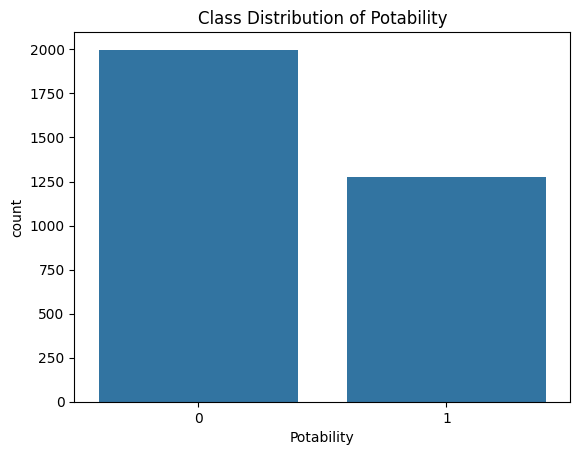

In [ ]:
sns.countplot(x='Potability', data=df)
plt.title('Class Distribution of Potability')
plt.show()

### **Check for outliers**

Using Boxplots

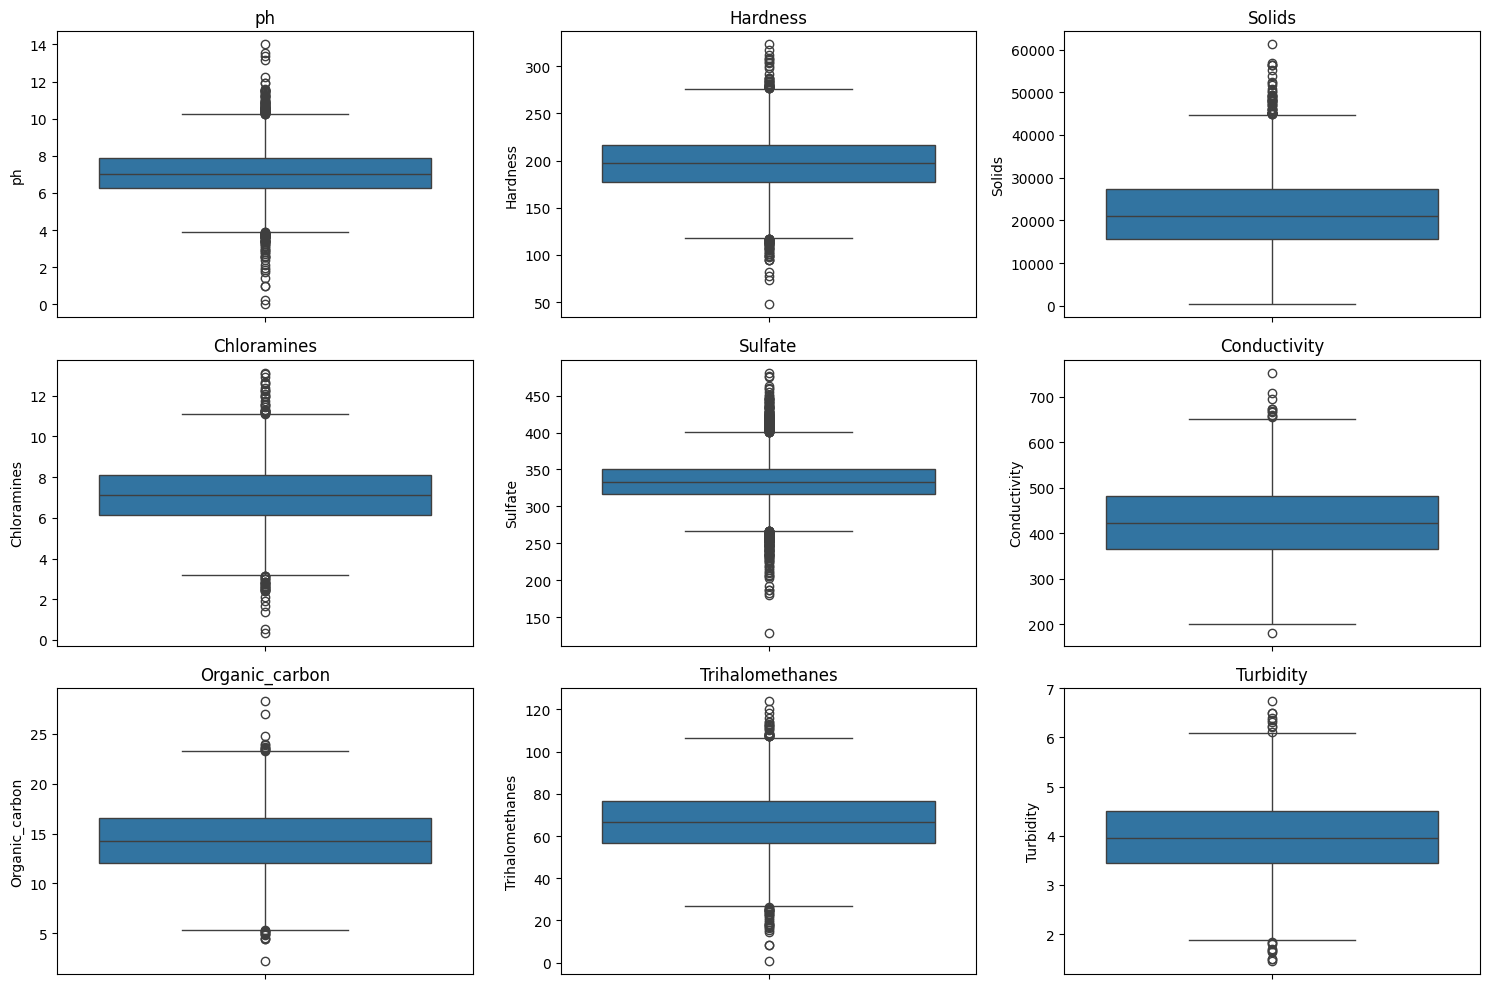

In [63]:
features = df.drop('Potability', axis=1).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Using IQR method

In [64]:
outlier_indices = set()

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outlier_indices.update(outliers)

print("Total outlier rows:", len(outlier_indices))

Total outlier rows: 610


### **Data split**

Split features and target

In [115]:
X = df.drop('Potability', axis=1)
y = df['Potability']

Train-test split (stratify to keep imbalance ratio)

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# **Random Forest**

In [105]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       400
           1       0.83      0.61      0.71       256

    accuracy                           0.80       656
   macro avg       0.81      0.77      0.78       656
weighted avg       0.80      0.80      0.79       656



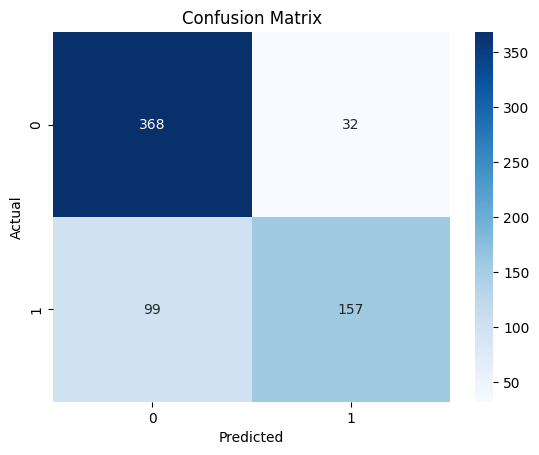

In [106]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Using SMOTE**

In [82]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

model.fit(X_train_res, y_train_res)
y_pred_res = model.predict(X_test)


print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       400
           1       0.83      0.61      0.71       256

    accuracy                           0.80       656
   macro avg       0.81      0.77      0.78       656
weighted avg       0.80      0.80      0.79       656



# **XGBoost**

In [102]:
model = xgb.XGBClassifier(
    n_estimators=300,        
    max_depth=5,             
    learning_rate=0.05,      
    subsample=0.8,           
    colsample_bytree=0.8,   
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [103]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       400
           1       0.80      0.65      0.72       256

    accuracy                           0.80       656
   macro avg       0.80      0.77      0.78       656
weighted avg       0.80      0.80      0.80       656



c:\Users\Informatics\Desktop\master project\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:23:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


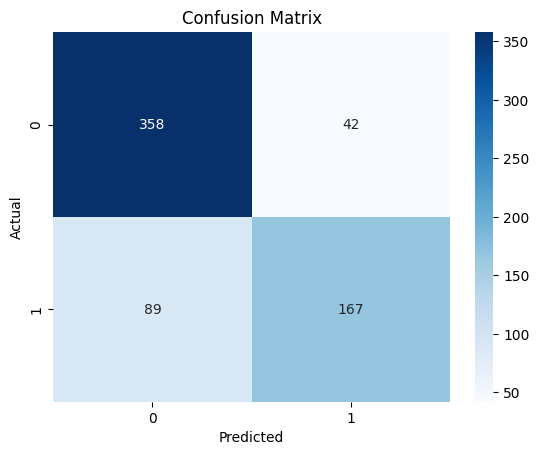

In [104]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Decision Tree**

In [117]:
dt_model = DecisionTreeClassifier(
    criterion='gini',  
    max_depth=5,
    random_state=42
)

In [118]:
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.93      0.81       400
           1       0.80      0.45      0.57       256

    accuracy                           0.74       656
   macro avg       0.76      0.69      0.69       656
weighted avg       0.75      0.74      0.72       656



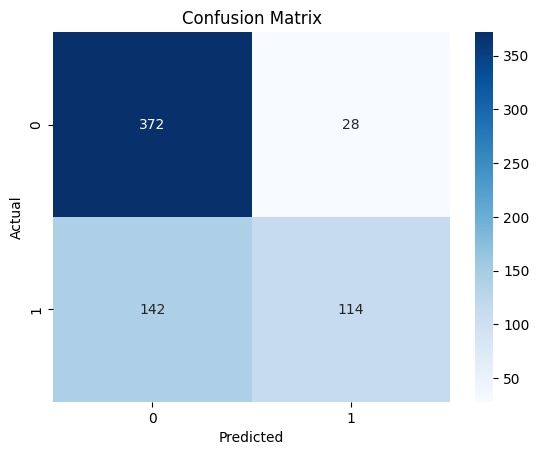

In [119]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Gradient Boosting**

In [121]:
model = GradientBoostingClassifier(
    n_estimators=300,       
    learning_rate=0.05,     
    max_depth=5,            
    subsample=0.8,          
    random_state=42
)

In [122]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.91      0.84       400
           1       0.81      0.61      0.70       256

    accuracy                           0.79       656
   macro avg       0.80      0.76      0.77       656
weighted avg       0.79      0.79      0.79       656



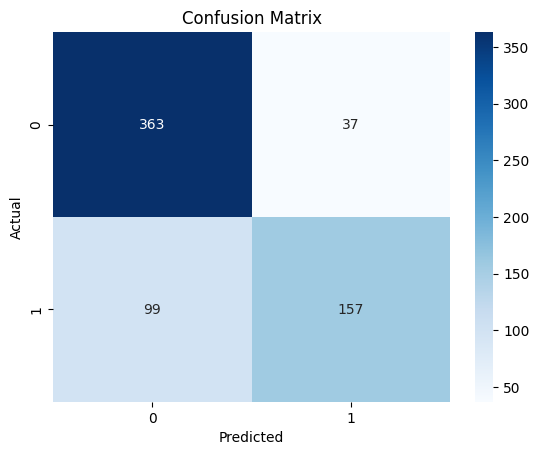

In [123]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **LightGBM**

In [126]:
model = lgb.LGBMClassifier(
    n_estimators=500,        
    max_depth=6,             
    learning_rate=0.05,      
    subsample=0.8,          
    colsample_bytree=0.8,    
    random_state=42
)

In [127]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

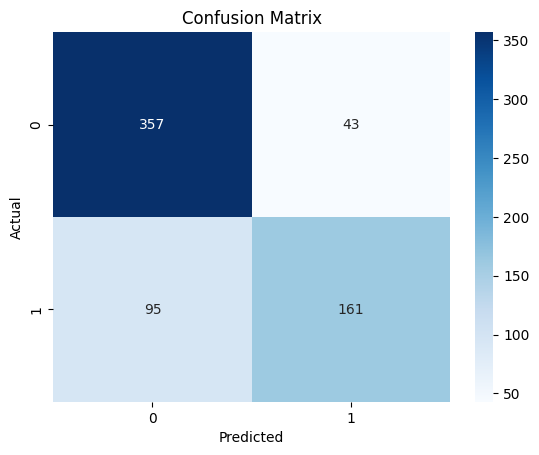

In [128]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **CatBoost**

In [131]:
model = CatBoostClassifier(
    iterations=1000,        
    learning_rate=0.05,     
    depth=6,                
    eval_metric='Accuracy', 
    random_seed=42,
    verbose=100,            
    early_stopping_rounds=50
)

In [132]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

0:	learn: 0.6954198	total: 135ms	remaining: 2m 14s
100:	learn: 0.8564885	total: 304ms	remaining: 2.71s
200:	learn: 0.8992366	total: 482ms	remaining: 1.92s
300:	learn: 0.9454198	total: 657ms	remaining: 1.52s
400:	learn: 0.9706107	total: 825ms	remaining: 1.23s
500:	learn: 0.9870229	total: 992ms	remaining: 988ms
600:	learn: 0.9931298	total: 1.16s	remaining: 773ms
700:	learn: 0.9965649	total: 1.33s	remaining: 568ms
800:	learn: 0.9977099	total: 1.5s	remaining: 373ms
900:	learn: 1.0000000	total: 1.67s	remaining: 184ms
999:	learn: 1.0000000	total: 1.86s	remaining: 0us
Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       400
           1       0.80      0.62      0.70       256

    accuracy                           0.79       656
   macro avg       0.79      0.76      0.77       656
weighted avg       0.79      0.79      0.79       656



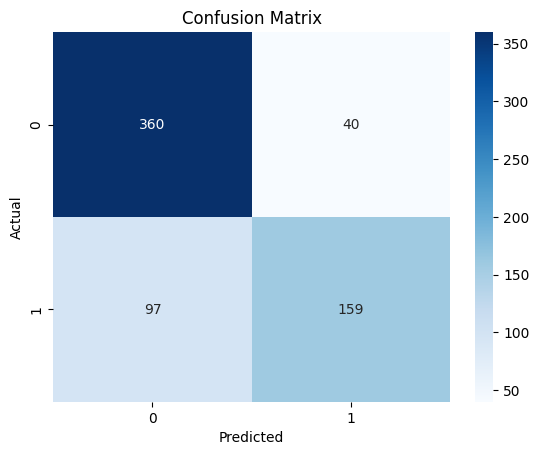

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **SVM with RBF kernel**

In [134]:
svm_model = SVC(
    kernel='rbf',
    C=10,           
    gamma='scale',  
    class_weight='balanced',  
    random_state=42
)

In [135]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

0:	learn: 0.6954198	total: 2.85ms	remaining: 2.84s
100:	learn: 0.8564885	total: 188ms	remaining: 1.68s
200:	learn: 0.8992366	total: 362ms	remaining: 1.44s
300:	learn: 0.9454198	total: 529ms	remaining: 1.23s
400:	learn: 0.9706107	total: 697ms	remaining: 1.04s
500:	learn: 0.9870229	total: 870ms	remaining: 866ms
600:	learn: 0.9931298	total: 1.04s	remaining: 693ms
700:	learn: 0.9965649	total: 1.22s	remaining: 519ms
800:	learn: 0.9977099	total: 1.39s	remaining: 345ms
900:	learn: 1.0000000	total: 1.56s	remaining: 171ms
999:	learn: 1.0000000	total: 1.73s	remaining: 0us
Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       400
           1       0.80      0.62      0.70       256

    accuracy                           0.79       656
   macro avg       0.79      0.76      0.77       656
weighted avg       0.79      0.79      0.79       656



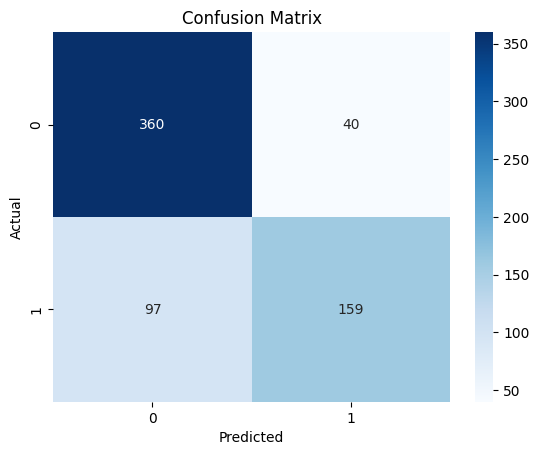

In [136]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()